# Center-Back Defensive Quality Analysis — 2024 Premier League

This notebook develops a data-driven **Ground Duel Quality Index** for center-backs (**CBs**) using dynamic Wyscout event data from the 2024 Premier League season. The analysis follows three main phases:

1. **Data preparation** — load all match events, filter to CB actions, and join reference datasets (players, teams, minutes).
2. **Metric construction** — extract ground-duel events, detect fouls via temporal proximity, classify duel outcomes, and compute rate and per-90 metrics.
3. **Quality index** — normalise metrics to z-scores, examine correlations, build a weighted composite score, and rank all qualifying CBs.

**Key output:** a ranked table of Premier League CBs by composite duel quality, covering duel success, possession recovery, discipline, and activity volume.

In [1]:
%matplotlib inline

### Library Imports

We import the core libraries used throughout this analysis: `pandas` and `numpy` for data manipulation, `json` and `pathlib` / `os` for file I/O, `matplotlib` and `mplsoccer` for pitch visualisations, and `statsmodels` for any statistical modelling steps. `%matplotlib inline` ensures plots render directly in the notebook.

In [2]:
# importing necessary libraries
import pandas as pd
import numpy as np
import json
# plotting
import matplotlib.pyplot as plt
from mplsoccer import VerticalPitch
# statistical fitting of models
import statsmodels.api as sm
import statsmodels.formula.api as smf
#opening data
import os
import pathlib
import warnings 

pd.options.mode.chained_assignment = None
warnings.filterwarnings('ignore')

## Opening 
We load data 2024 PL England


In [3]:
folder = os.path.join(
    str(pathlib.Path().resolve().parents[0]),
    "data",
    "data-CB_pairing_AI_analyst",
    "PL_2024_wyscout",
    "event_data"
)

files = os.listdir(folder)
len(files)

380

In [4]:

with open(folder + "/" + "5588080.json") as f:
    data = json.load(f)

# Option 1: If data is a list of events, use this:
data_test_df = pd.DataFrame(data["events"])
data_test_df

,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,relatedEventId,type,location,team,opponentTeam,player,pass,shot,groundDuel,aerialDuel,infraction,carry,possession
0,2263270078,5588080,1H,0,4,00:00:04.610,5.610889,2.263270e+09,"{'primary': 'pass', 'secondary': ['back_pass',...","{'x': 51, 'y': 50}","{'id': 1616, 'name': 'Fulham'}","{'id': 1611, 'name': 'Manchester United'}","{'id': 240445, 'name': 'Andreas Pereira', 'pos...","{'accurate': True, 'angle': 153, 'height': Non...",None,None,None,None,None,"{'id': 2263270078, 'duration': '9.1308335', 't..."
1,2263270076,5588080,1H,0,6,00:00:06.178,7.178286,2.263270e+09,"{'primary': 'pass', 'secondary': ['back_pass',...","{'x': 38, 'y': 61}","{'id': 1616, 'name': 'Fulham'}","{'id': 1611, 'name': 'Manchester United'}","{'id': 237269, 'name': 'S. Lukić', 'position':...","{'accurate': True, 'angle': 137, 'height': Non...",None,None,None,None,None,"{'id': 2263270078, 'duration': '9.1308335', 't..."
2,2263270077,5588080,1H,0,11,00:00:11.472,12.472906,2.263270e+09,"{'primary': 'pass', 'secondary': ['forward_pas...","{'x': 24, 'y': 81}","{'id': 1616, 'name': 'Fulham'}","{'id': 1611, 'name': 'Manchester United'}","{'id': 286380, 'name': 'I. Diop', 'position': ...","{'accurate': True, 'angle': 9, 'height': None,...",None,None,None,None,None,"{'id': 2263270078, 'duration': '9.1308335', 't..."
3,2263270079,5588080,1H,0,13,00:00:13.283,14.283666,2.263270e+09,"{'primary': 'duel', 'secondary': ['ground_duel...","{'x': 64, 'y': 91}","{'id': 1616, 'name': 'Fulham'}","{'id': 1611, 'name': 'Manchester United'}","{'id': 225947, 'name': 'Adama Traoré', 'positi...",None,None,"{'opponent': {'id': 369589, 'name': 'Diogo Dal...",None,None,None,"{'id': 2263270078, 'duration': '9.1308335', 't..."
4,2263270083,5588080,1H,0,14,00:00:14.199,15.199779,2.263270e+09,"{'primary': 'duel', 'secondary': ['defensive_d...","{'x': 36, 'y': 9}","{'id': 1611, 'name': 'Manchester United'}","{'id': 1616, 'name': 'Fulham'}","{'id': 369589, 'name': 'Diogo Dalot', 'positio...",None,None,"{'opponent': {'id': 225947, 'name': 'Adama Tra...",None,None,None,"{'id': 2263270083, 'duration': '9.219295', 'ty..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1606,2263271790,5588080,2H,94,20,01:34:20.113,5734.113979,2.263272e+09,"{'primary': 'pass', 'secondary': ['back_pass',...","{'x': 41, 'y': 25}","{'id': 1611, 'name': 'Manchester United'}","{'id': 1616, 'name': 'Fulham'}","{'id': 397174, 'name': 'S. McTominay', 'positi...","{'accurate': True, 'angle': 180, 'height': Non...",None,None,None,None,None,"{'id': 2263271788, 'duration': '10.8279635', '..."
1607,2263271792,5588080,2H,94,21,01:34:21.292,5735.292554,2.263272e+09,"{'primary': 'pass', 'secondary': ['back_pass',...","{'x': 30, 'y': 25}","{'id': 1611, 'name': 'Manchester United'}","{'id': 1616, 'name': 'Fulham'}","{'id': 488453, 'name': 'L. Martínez', 'positio...","{'accurate': True, 'angle': 142, 'height': Non...",None,None,None,None,None,"{'id': 2263271788, 'duration': '10.8279635', '..."
1608,2263271794,5588080,2H,94,25,01:34:25.879,5739.879353,2.263272e+09,"{'primary': 'pass', 'secondary': ['forward_pas...","{'x': 5, 'y': 56}","{'id': 1611, 'name': 'Manchester United'}","{'id': 1616, 'name': 'Fulham'}","{'id': 344038, 'name': 'A. Onana', 'position':...","{'accurate': False, 'angle': 30, 'height': 'hi...",None,None,None,None,None,"{'id': 2263271788, 'duration': '10.8279635', '..."
1609,2263271797,5588080,2H,94,32,01:34:32.461,5746.461904,NaN,"{'primary': 'game_interruption', 'secondary': ...","{'x': 55, 'y': 100}","{'id': 1611, 'name': 'Manchester United'}","{'id': 1616, 'name': 'Fulham'}","{'id': 0, 'name': None, 'position': None}",None,None,None,None,None,None,"{'id': 2263271788, 'duration': '10.8279635', '..."


### Loading All Match Event Files

We combine every match JSON file into a single DataFrame using `pd.concat` with a list comprehension. `pd.json_normalize` flattens each match's nested event objects into columns. `ignore_index=True` ensures the final index is contiguous. The resulting `events_df` contains every on-ball action for the entire 2024 Premier League season.

In [5]:
events_df = pd.concat(
    [
        pd.json_normalize(json.load(open(os.path.join(folder, f)))["events"])
        for f in files if f.endswith(".json")
    ],
    ignore_index=True
)

In [6]:
events_df.shape
events_df["matchId"].nunique()

380

## Extracting CB Events

To begin constructing defensive quality metrics, we first isolate the events generated by CBs during the season.

In [7]:
events_df["player.position"].unique()

array(['RCMF', 'LCMF', 'RCB', 'RW', 'LB', 'LDMF', 'LAMF', 'RDMF', 'LCB',
       'CF', 'RB', 'RAMF', 'GK', 'SS', 'AMF', 'LW', None, 'DMF', 'LCMF3',
       'LWF', 'RCMF3', 'RWF', 'CB', 'RB5', 'LB5', 'RCB3', 'LCB3', 'LWB',
       'RWB'], dtype=object)

In [8]:
cb_positions = ["CB", "LCB", "RCB", "LCB3", "RCB3"]

cb_events = events_df[
    events_df["player.position"].isin(cb_positions)
]

cb_events

,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,relatedEventId,shot,groundDuel,...,shot.postShotXg,shot.goalkeeperActionId,shot.goalkeeper,possession,shot.goalkeeper.id,shot.goalkeeper.name,infraction.opponent,location,groundDuel.opponent,aerialDuel.opponent
2,2263270077,5588080,1H,0,11,00:00:11.472,12.472906,2.263270e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2263270081,5588080,1H,0,18,00:00:18.691,19.691963,2.263270e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,2263270086,5588080,1H,0,59,00:00:59.478,60.478406,2.263270e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,2263270094,5588080,1H,1,4,00:01:04.490,65.490945,2.263270e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26,2263270102,5588080,1H,1,19,00:01:19.811,80.811002,2.263270e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
630247,2556250900,5588459,2H,93,29,01:33:29.055,5703.055063,2.556251e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
630254,2556250895,5588459,2H,94,19,01:34:19.509,5753.509122,2.556251e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
630255,2556250894,5588459,2H,94,20,01:34:20.033,5754.033937,2.556251e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
630258,2556250898,5588459,2H,94,23,01:34:23.850,5757.850849,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
#load data - store it in data_england_df dataframe
data_england_df = pd.DataFrame()

### Single-Match Structure Exploration

To understand the schema of the Wyscout data, we open and inspect a single match JSON file in detail. This helps us identify relevant column names before we process the full dataset. `pd.json_normalize` flattens the nested event objects into a tabular format.

In [10]:
file_name = f'5588081.json'
path = os.path.join(str(pathlib.Path().resolve().parents[0]), "data", "data-CB_pairing_AI_analyst", "PL_2024_wyscout", "event_data", file_name)

with open(path) as f:
    data = json.load(f)

type(data)

dict

In [11]:
data.keys()

dict_keys(['meta', 'events', 'match', 'substitutions', 'teams', 'players'])

In [12]:
data_england_ = pd.DataFrame(data["events"])
data_england_

,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,relatedEventId,type,location,team,opponentTeam,player,pass,shot,groundDuel,aerialDuel,infraction,carry,possession
0,2264027646,5588081,1H,0,0,00:00:00.654,1.654401,2.264028e+09,"{'primary': 'pass', 'secondary': ['back_pass',...","{'x': 51, 'y': 50}","{'id': 1612, 'name': 'Liverpool'}","{'id': 1634, 'name': 'Ipswich Town'}","{'id': 476382, 'name': 'D. Szoboszlai', 'posit...","{'accurate': True, 'angle': 173, 'height': Non...",None,None,None,None,None,"{'id': 2264027646, 'duration': '25.3317015', '..."
1,2264027649,5588081,1H,0,4,00:00:04.326,5.326884,2.264028e+09,"{'primary': 'pass', 'secondary': ['forward_pas...","{'x': 27, 'y': 55}","{'id': 1612, 'name': 'Liverpool'}","{'id': 1634, 'name': 'Ipswich Town'}","{'id': 214220, 'name': 'Alisson', 'position': ...","{'accurate': True, 'angle': -28, 'height': 'hi...",None,None,None,None,None,"{'id': 2264027646, 'duration': '25.3317015', '..."
2,2264027650,5588081,1H,0,7,00:00:07.278,8.278039,2.264028e+09,"{'primary': 'duel', 'secondary': ['aerial_duel']}","{'x': 73, 'y': 16}","{'id': 1612, 'name': 'Liverpool'}","{'id': 1634, 'name': 'Ipswich Town'}","{'id': 345621, 'name': 'Diogo Jota', 'position...",None,None,None,"{'opponent': {'id': 397163, 'name': 'A. Tuanze...",None,None,"{'id': 2264027646, 'duration': '25.3317015', '..."
3,2264027671,5588081,1H,0,7,00:00:07.371,8.371551,2.264028e+09,"{'primary': 'duel', 'secondary': ['aerial_duel']}","{'x': 27, 'y': 84}","{'id': 1634, 'name': 'Ipswich Town'}","{'id': 1612, 'name': 'Liverpool'}","{'id': 397163, 'name': 'A. Tuanzebe', 'positio...",None,None,None,"{'opponent': {'id': 345621, 'name': 'Diogo Jot...",None,None,"{'id': 2264027646, 'duration': '25.3317015', '..."
4,2264027651,5588081,1H,0,13,00:00:13.630,14.630505,2.264028e+09,"{'primary': 'pass', 'secondary': ['back_pass',...","{'x': 93, 'y': 14}","{'id': 1612, 'name': 'Liverpool'}","{'id': 1634, 'name': 'Ipswich Town'}","{'id': 431967, 'name': 'L. Díaz', 'position': ...","{'accurate': True, 'angle': -135, 'height': No...",None,None,None,None,None,"{'id': 2264027646, 'duration': '25.3317015', '..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,2264029746,5588081,2H,97,54,01:37:54.366,5953.366007,2.264029e+09,"{'primary': 'pass', 'secondary': ['forward_pas...","{'x': 59, 'y': 41}","{'id': 1634, 'name': 'Ipswich Town'}","{'id': 1612, 'name': 'Liverpool'}","{'id': 460321, 'name': 'J. Taylor', 'position'...","{'accurate': False, 'angle': -12, 'height': 'h...",None,None,None,None,None,"{'id': 2264029735, 'duration': '29.0688565', '..."
1639,2264029305,5588081,2H,97,56,01:37:56.104,5955.104968,2.264029e+09,"{'primary': 'interception', 'secondary': ['for...","{'x': 19, 'y': 66}","{'id': 1612, 'name': 'Liverpool'}","{'id': 1634, 'name': 'Ipswich Town'}","{'id': 631619, 'name': 'C. Bradley', 'position...","{'accurate': True, 'angle': -7, 'height': 'hig...",None,None,None,None,None,"{'id': 2264029305, 'duration': '7.855347', 'ty..."
1640,2264029306,5588081,2H,97,59,01:37:59.687,5958.687012,2.264029e+09,"{'primary': 'pass', 'secondary': ['lateral_pas...","{'x': 34, 'y': 63}","{'id': 1612, 'name': 'Liverpool'}","{'id': 1634, 'name': 'Ipswich Town'}","{'id': 535824, 'name': 'R. Gravenberch', 'posi...","{'accurate': True, 'angle': -76, 'height': Non...",None,None,None,None,None,"{'id': 2264029305, 'duration': '7.855347', 'ty..."
1641,2264029307,5588081,2H,98,1,01:38:01.569,5960.569212,2.264029e+09,"{'primary': 'pass', 'secondary': ['forward_pas...","{'x': 42, 'y': 17}","{'id': 1612, 'name': 'Liverpool'}","{'id': 1634, 'name': 'Ipswich Town'}","{'id': 344181, 'name': 'K. Tsimikas', 'positio...","{'accurate': True, 'angle': -24, 'height': Non...",None,None,None,None,None,"{'id': 2264029305, 'duration': '7.855347', 'ty..."


In [13]:
data_england_df = pd.json_normalize(data["events"])
data_england_df

,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,relatedEventId,shot,groundDuel,...,shot.goalkeeper,infraction.yellowCard,infraction.redCard,infraction.type,infraction.opponent.id,infraction.opponent.name,infraction.opponent.position,shot.goalkeeper.id,shot.goalkeeper.name,infraction.opponent
0,2264027646,5588081,1H,0,0,00:00:00.654,1.654401,2.264028e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2264027649,5588081,1H,0,4,00:00:04.326,5.326884,2.264028e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2264027650,5588081,1H,0,7,00:00:07.278,8.278039,2.264028e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2264027671,5588081,1H,0,7,00:00:07.371,8.371551,2.264028e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2264027651,5588081,1H,0,13,00:00:13.630,14.630505,2.264028e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,2264029746,5588081,2H,97,54,01:37:54.366,5953.366007,2.264029e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1639,2264029305,5588081,2H,97,56,01:37:56.104,5955.104968,2.264029e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1640,2264029306,5588081,2H,97,59,01:37:59.687,5958.687012,2.264029e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1641,2264029307,5588081,2H,98,1,01:38:01.569,5960.569212,2.264029e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
data_england_df.columns

Index(['id', 'matchId', 'matchPeriod', 'minute', 'second', 'matchTimestamp',
       'videoTimestamp', 'relatedEventId', 'shot', 'groundDuel', 'aerialDuel',
       'infraction', 'carry', 'type.primary', 'type.secondary', 'location.x',
       'location.y', 'team.id', 'team.name', 'opponentTeam.id',
       'opponentTeam.name', 'player.id', 'player.name', 'player.position',
       'pass.accurate', 'pass.angle', 'pass.height', 'pass.length',
       'pass.recipient.id', 'pass.recipient.name', 'pass.recipient.position',
       'pass.endLocation.x', 'pass.endLocation.y', 'possession.id',
       'possession.duration', 'possession.types', 'possession.eventsNumber',
       'possession.eventIndex', 'possession.startLocation.x',
       'possession.startLocation.y', 'possession.endLocation.x',
       'possession.endLocation.y', 'possession.team.id',
       'possession.team.name', 'possession.attack.withShot',
       'possession.attack.withShotOnGoal', 'possession.attack.withGoal',
       'possession

## Loading Reference Data

In addition to the raw event log, we load four supporting datasets stored as Parquet files: **players** (player metadata and positions), **teams** (club information), **minutes** (playing time per player per match), and **matches** (fixture metadata). These will be joined to the events data to enrich player-level summaries.

### Players

In [15]:
parquet_path = os.path.join(str(pathlib.Path().resolve().parents[0]), "data", "data-CB_pairing_AI_analyst", "PL_2024_wyscout/")

players_england_df = pd.read_parquet(parquet_path + "players.parquet")
players_england_df

,player_id,short_name,first_name,last_name,birth_date,height,weight,passport,birth_country,image_url,gender,foot,role,team_id,season_id
0,1096014,T. Edozie,Tom,Edozie,2006-05-18,0,0,England,England,https://cdn5.wyscout.com/photos/players/public...,male,right,Forward,22988,189908
1,1050460,J. Monga,Jeremy,Monga,2009-07-10,0,0,England,England,https://cdn5.wyscout.com/photos/players/public...,male,0,Forward,25891,189908
2,1046087,M. Mane,Mateus,Mane,2007-09-16,0,0,England,England,https://cdn5.wyscout.com/photos/players/public...,male,0,Forward,2339,189908
3,961676,Y. Konak,Yunus Emre,Konak,2006-01-10,181,72,Turkey,Turkey,https://cdn5.wyscout.com/photos/players/public...,male,right,Midfielder,1669,189908
4,960198,J. Moore,Jayden,Moore,1970-01-01,0,0,England,England,https://cdn5.wyscout.com/photos/players/public...,male,right,Defender,22977,189908
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
679,543978,D. Núñez,Darwin Gabriel,Núñez Ribeiro,1999-06-24,186,80,Uruguay,Uruguay,https://cdn5.wyscout.com/photos/players/public...,male,right,Forward,1612,189908
680,544911,N. Patterson,Nathan,Patterson,2001-10-16,183,72,Scotland,Scotland,https://cdn5.wyscout.com/photos/players/public...,male,right,Defender,1623,189908
681,545267,R. Drăgușin,Radu,Drăgușin,2002-02-03,191,82,Romania,Romania,https://cdn5.wyscout.com/photos/players/public...,male,right,Defender,1624,189908
682,545295,H. Graczyk,Hubert,Graczyk,2003-02-28,187,76,England,Poland,https://cdn5.wyscout.com/photos/players/public...,male,right,Goalkeeper,22975,189908


In [16]:
players_england_df.columns

Index(['player_id', 'short_name', 'first_name', 'last_name', 'birth_date',
       'height', 'weight', 'passport', 'birth_country', 'image_url', 'gender',
       'foot', 'role', 'team_id', 'season_id'],
      dtype='object')

### Teams

In [17]:
teams_england_df = pd.read_parquet(parquet_path + "teams.parquet")
teams_england_df

,team_id,name,official_name,country,image_url,gender,season_id
0,1609,Arsenal,Arsenal FC,England,https://cdn5.wyscout.com/photos/team/public/21...,male,189908
1,1610,Chelsea,Chelsea FC,England,https://cdn5.wyscout.com/photos/team/public/25...,male,189908
2,1611,Manchester United,Manchester United FC,England,https://cdn5.wyscout.com/photos/team/public/22...,male,189908
3,1612,Liverpool,Liverpool FC,England,https://cdn5.wyscout.com/photos/team/public/24...,male,189908
4,1613,Newcastle United,Newcastle United FC,England,https://cdn5.wyscout.com/photos/team/public/36...,male,189908
5,1614,Aston Villa,Aston Villa FC,England,https://cdn5.wyscout.com/photos/team/public/32...,male,189908
6,1616,Fulham,Fulham FC,England,https://cdn5.wyscout.com/photos/team/public/29...,male,189908
7,1619,Southampton,Southampton FC,England,https://cdn5.wyscout.com/photos/team/public/30...,male,189908
8,1623,Everton,Everton FC,England,https://cdn5.wyscout.com/photos/team/public/37...,male,189908
9,1624,Tottenham Hotspur,Tottenham Hotspur FC,England,https://cdn5.wyscout.com/photos/team/public/26...,male,189908


In [18]:
teams_england_df.columns

Index(['team_id', 'name', 'official_name', 'country', 'image_url', 'gender',
       'season_id'],
      dtype='object')

### Minutes

In [19]:
minutes_england_df = pd.read_parquet(parquet_path + "minutes.parquet")
minutes_england_df

,player_id,minutes_played,position_provider,position,jersey_number,team_id,match_id,yellow_card,bookings,red_card,goals,assists,sub_in,sub_out,minutes,own_goals,starting,competition,season
0,583656,61,RAMF,Winger,16,1611,5588080,False,0,False,0,0,0,61,61,0,True,364,2024
1,346139,61,AMF,Midfielder,7,1611,5588080,True,1,False,0,0,0,61,61,0,True,364,2024
2,8653,81,RCB,Central Defender,5,1611,5588080,True,1,False,0,0,0,81,81,0,True,364,2024
3,349142,81,RB,Full Back,3,1611,5588080,False,0,False,0,0,0,81,81,0,True,364,2024
4,692544,84,LDMF,Midfielder,37,1611,5588080,False,0,False,0,0,0,84,84,0,True,364,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11562,286368,90,CF,Striker,11,1669,5588459,True,1,False,0,0,0,0,90,0,True,364,2024
11563,621262,90,LDMF,Midfielder,18,1669,5588459,False,0,False,0,0,0,0,90,0,True,364,2024
11564,607630,14,LAMF,Winger,9,1669,5588459,False,0,False,0,0,80,0,10,0,False,364,2024
11565,361163,14,AMF,Midfielder,8,1669,5588459,False,0,False,0,0,80,0,10,0,False,364,2024


### Matches

In [20]:
matches_england_df = pd.read_parquet(parquet_path + "matches.parquet")
matches_england_df

,match_id,competition_id,season_id,date,label,gameweek,home_team_id,away_team_id,home_team_name,away_team_name,home_team_score,away_team_score,status,home_coach_id,away_coach_id,competition,season
0,5588368,364,189908,2025-04-16 20:30:00,"Newcastle United - Crystal Palace, 5-0",29,1613,1628,Newcastle United,Crystal Palace,5,0,Played,8934,753418,364,2024
1,5588095,364,189908,2024-08-25 17:30:00,"Liverpool - Brentford, 2-0",2,1612,1669,Liverpool,Brentford,2,0,Played,753720,135095,364,2024
2,5588282,364,189908,2025-01-15 20:30:00,"Everton - Aston Villa, 0-1",21,1623,1614,Everton,Aston Villa,0,1,Played,8235,3265,364,2024
3,5588329,364,189908,2025-02-15 16:00:00,"West Ham United - Brentford, 0-1",25,1633,1669,West Ham United,Brentford,0,1,Played,51607,135095,364,2024
4,5588443,364,189908,2025-05-19 21:00:00,"Brighton - Liverpool, 3-2",37,1651,1612,Brighton,Liverpool,3,2,Played,18554,753720,364,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375,5588199,364,189908,2024-11-24 15:00:00,"Southampton - Liverpool, 2-3",12,1619,1612,Southampton,Liverpool,2,3,Played,641939,753720,364,2024
376,5588212,364,189908,2024-12-05 21:15:00,"Bournemouth - Tottenham Hotspur, 1-0",14,1659,1624,Bournemouth,Tottenham Hotspur,1,0,Played,575112,61546,364,2024
377,5588234,364,189908,2024-12-14 16:00:00,"Liverpool - Fulham, 2-2",16,1612,1616,Liverpool,Fulham,2,2,Played,753720,71037,364,2024
378,5588354,364,189908,2025-03-08 16:00:00,"Liverpool - Southampton, 3-1",28,1612,1619,Liverpool,Southampton,3,1,Played,753720,753322,364,2024


In [21]:
matches_england_df.columns

Index(['match_id', 'competition_id', 'season_id', 'date', 'label', 'gameweek',
       'home_team_id', 'away_team_id', 'home_team_name', 'away_team_name',
       'home_team_score', 'away_team_score', 'status', 'home_coach_id',
       'away_coach_id', 'competition', 'season'],
      dtype='object')

In [22]:
# Debug: Check what type data is and print a sample
print(f"Data type: {type(data)}")
if isinstance(data, dict):
    print(f"Keys: {list(data.keys())}")
    # Print first few items of each key to understand structure
    for key in list(data.keys())[:3]:
        print(f"\n{key}: {type(data[key])}")
        if isinstance(data[key], list) and len(data[key]) > 0:
            print(f"First item: {data[key][0]}")
elif isinstance(data, list):
    print(f"List length: {len(data)}")
    if len(data) > 0:
        print(f"First item type: {type(data[0])}")
        print(f"First item: {data[0]}")

Data type: <class 'dict'>
Keys: ['meta', 'events', 'match', 'substitutions', 'teams', 'players']

meta: <class 'list'>

events: <class 'list'>
First item: {'id': 2264027646, 'matchId': 5588081, 'matchPeriod': '1H', 'minute': 0, 'second': 0, 'matchTimestamp': '00:00:00.654', 'videoTimestamp': '1.654401', 'relatedEventId': 2264027649, 'type': {'primary': 'pass', 'secondary': ['back_pass', 'short_or_medium_pass']}, 'location': {'x': 51, 'y': 50}, 'team': {'id': 1612, 'name': 'Liverpool'}, 'opponentTeam': {'id': 1634, 'name': 'Ipswich Town'}, 'player': {'id': 476382, 'name': 'D. Szoboszlai', 'position': 'AMF'}, 'pass': {'accurate': True, 'angle': 173, 'height': None, 'length': 25, 'recipient': {'id': 214220, 'name': 'Alisson', 'position': 'GK'}, 'endLocation': {'x': 27, 'y': 55}}, 'shot': None, 'groundDuel': None, 'aerialDuel': None, 'infraction': None, 'carry': None, 'possession': {'id': 2264027646, 'duration': '25.3317015', 'types': ['attack'], 'eventsNumber': 15, 'eventIndex': 0, 'start

# Qualities
By filtering the event dataset using these labels, we obtain a subset of events corresponding only to CBs. This filtered dataset will be used to compute basic defensive metrics such as:

- **Duel dominance** – ability to win ground duels   
- **Defensive aggression** – frequency of engaging in defensive duels  

These metrics will later be normalized and combined into a simple defensive quality index.

### Exploring CB Event Structure

Before calculating metrics, we explore the available columns and infraction fields in the CB event subset. Understanding which fields exist (and their unique values) is essential for correctly identifying fouls, yellow cards, and red cards that occurred during defensive actions.

In [23]:
cb_events["infraction.type"].unique()

array([nan, 'regular_foul', 'simulation_foul', 'out_of_play_foul',
       'time_lost_foul', 'late_card_foul', 'protest_foul', 'hand_foul'],
      dtype=object)

In [24]:
cb_events.columns

Index(['id', 'matchId', 'matchPeriod', 'minute', 'second', 'matchTimestamp',
       'videoTimestamp', 'relatedEventId', 'shot', 'groundDuel', 'aerialDuel',
       'infraction', 'carry', 'type.primary', 'type.secondary', 'location.x',
       'location.y', 'team.id', 'team.name', 'opponentTeam.id',
       'opponentTeam.name', 'player.id', 'player.name', 'player.position',
       'pass.accurate', 'pass.angle', 'pass.height', 'pass.length',
       'pass.recipient.id', 'pass.recipient.name', 'pass.recipient.position',
       'pass.endLocation.x', 'pass.endLocation.y', 'possession.id',
       'possession.duration', 'possession.types', 'possession.eventsNumber',
       'possession.eventIndex', 'possession.startLocation.x',
       'possession.startLocation.y', 'possession.endLocation.x',
       'possession.endLocation.y', 'possession.team.id',
       'possession.team.name', 'possession.attack', 'pass',
       'groundDuel.opponent.id', 'groundDuel.opponent.name',
       'groundDuel.opponent.pos

In [25]:
cb_events["infraction.yellowCard"].unique()

array([nan, False, True], dtype=object)

In [26]:
cb_events["infraction.redCard"].unique()

array([nan, False, True], dtype=object)

### Ground Duels

### Filtering to Defensive Ground Duels

From all CB events, we isolate those tagged as **defensive ground duels** (`groundDuel.duelType == 'defensive'`). These are the one-on-one challenges where a CB attempts to stop an opponent carrying the ball. We also collect foul events separately so we can later link them back to the duel that triggered them.

In [27]:
duel_cols = [
    "player.id",
    "player.name",
    "matchTimestamp",
    "infraction.type",
    "groundDuel.duelType",
    "groundDuel.stoppedProgress",
    "groundDuel.recoveredPossession",
    "groundDuel.takeOn",
    'groundDuel.opponent.id',
    'groundDuel.opponent.name', 'groundDuel.opponent.position',
]
ground_duels = cb_events[
    (cb_events["groundDuel.duelType"] == "defensive_duel") | (cb_events["infraction.type"] == 'regular_foul')
]
ground_duels[duel_cols].head(20)

,player.id,player.name,matchTimestamp,infraction.type,groundDuel.duelType,groundDuel.stoppedProgress,groundDuel.recoveredPossession,groundDuel.takeOn,groundDuel.opponent.id,groundDuel.opponent.name,groundDuel.opponent.position
9,286380,I. Diop,00:00:18.691,NaN,defensive_duel,False,False,True,397178.0,M. Rashford,LAMF
120,488453,L. Martínez,00:06:35.471,NaN,defensive_duel,False,False,True,225947.0,Adama Traoré,RW
146,488453,L. Martínez,00:07:46.434,NaN,defensive_duel,True,False,False,0.0,None,None
179,8653,H. Maguire,00:09:25.194,NaN,defensive_duel,False,False,False,488326.0,Rodrigo Muniz,CF
180,8653,H. Maguire,00:09:27.556,regular_foul,NaN,NaN,NaN,NaN,NaN,NaN,NaN
275,286380,I. Diop,00:15:43.544,NaN,defensive_duel,True,False,False,397178.0,M. Rashford,LAMF
280,488453,L. Martínez,00:15:51.992,NaN,defensive_duel,True,False,False,225947.0,Adama Traoré,RW
424,447424,C. Bassey,00:22:59.643,NaN,defensive_duel,False,False,True,692544.0,K. Mainoo,LDMF
426,447424,C. Bassey,00:23:01.674,regular_foul,NaN,NaN,NaN,NaN,NaN,NaN,NaN
447,447424,C. Bassey,00:24:53.791,NaN,defensive_duel,False,False,False,346139.0,M. Mount,AMF


In [28]:
print("ground duels unique", ground_duels["groundDuel.duelType"].unique())
print("ground duel infraction type", ground_duels["infraction.type"].unique())
print("ground duels kept possession unique", ground_duels["groundDuel.keptPossession"].unique())
print("ground duels progressed with ball", ground_duels["groundDuel.progressedWithBall"].unique())
print("ground duels stopped progress unique", ground_duels["groundDuel.stoppedProgress"].unique())
print("ground duels recovered possession unique", ground_duels["groundDuel.recoveredPossession"].unique())

ground duels unique ['defensive_duel' nan]
ground duel infraction type [nan 'regular_foul']
ground duels kept possession unique [None nan]
ground duels progressed with ball [None nan]
ground duels stopped progress unique [False True nan]
ground duels recovered possession unique [False nan True]


## Ground Duel Foul Detection

We need to identify which defensive duels resulted in fouls to properly assess defensive quality. The challenge is that fouls are recorded as separate events from the duel itself.

### Why we do this:

1. **Separate event recording**: In the Wyscout data, a defensive duel and the resulting foul are logged as two distinct events
2. **Quality assessment**: A duel that results in a foul indicates aggressive but potentially flawed defensive execution
3. **Temporal proximity**: We only link duels to fouls if they occur within 1.3 second of each other by the same player

In [29]:
def timestamp_to_seconds(ts):
    """Convert HH:MM:SS.milliseconds to total seconds"""
    if pd.isna(ts):
        return np.nan
    h, m, s = ts.split(':')
    return int(h) * 3600 + int(m) * 60 + float(s)


# Work on a copy so the original ground_duels DataFrame is preserved
ground_duels_with_fouls = ground_duels.copy()

ground_duels_with_fouls["next_event_foul"] = (
    ground_duels["infraction.type"].shift(-1) == "regular_foul"
)

ground_duels_with_fouls["next_player_same"] = (
    ground_duels["player.id"] == ground_duels["player.id"].shift(-1)
)

ground_duels_with_fouls["foul_timestamp_seconds"] = ground_duels["matchTimestamp"].apply(timestamp_to_seconds).shift(-1)
ground_duels_with_fouls["match_timestamp_seconds"] = ground_duels["matchTimestamp"].apply(timestamp_to_seconds)

ground_duels_with_fouls["time_diff"] = (
    ground_duels_with_fouls["foul_timestamp_seconds"] - ground_duels_with_fouls["match_timestamp_seconds"]
)

ground_duels_with_fouls["yellowCard_shift"] = ground_duels_with_fouls["infraction.yellowCard"].shift(-1)
ground_duels_with_fouls["redCard_shift"] = ground_duels_with_fouls["infraction.redCard"].shift(-1)

ground_duels_with_fouls["duel_resulted_foul"] = (
    ground_duels_with_fouls["next_event_foul"] &
    ground_duels_with_fouls["next_player_same"] &
    (ground_duels_with_fouls["time_diff"] <= 1.3)
)

ground_duels_with_fouls["yellowCard"] = ground_duels_with_fouls["yellowCard_shift"].where(
    ground_duels_with_fouls["duel_resulted_foul"],
    False
)

ground_duels_with_fouls["redCard"] = ground_duels_with_fouls["redCard_shift"].where(
    ground_duels_with_fouls["duel_resulted_foul"],
    False
)

# Drop rows where infraction.type is regular_foul
ground_duels_with_fouls = ground_duels_with_fouls[ground_duels_with_fouls["infraction.type"] != "regular_foul"]

# After the duel_resulted_foul flag
ground_duels_with_fouls["unsuccessful_duel"] = (
    ~ground_duels_with_fouls["duel_resulted_foul"] &
    (ground_duels_with_fouls["groundDuel.stoppedProgress"] == False) &
    (ground_duels_with_fouls["groundDuel.recoveredPossession"] == False)
)

duel_cols = [
    "player.id",
    "player.name",
    "matchTimestamp",
    "duel_resulted_foul",
    "groundDuel.duelType",
    "groundDuel.stoppedProgress",
    "groundDuel.recoveredPossession",
    "unsuccessful_duel",
    "groundDuel.takeOn",
    "yellowCard",
    "redCard",
    'groundDuel.opponent.id',
    'groundDuel.opponent.name',
]

ground_duels_with_fouls[duel_cols].head(20)

,player.id,player.name,matchTimestamp,duel_resulted_foul,groundDuel.duelType,groundDuel.stoppedProgress,groundDuel.recoveredPossession,unsuccessful_duel,groundDuel.takeOn,yellowCard,redCard,groundDuel.opponent.id,groundDuel.opponent.name
9,286380,I. Diop,00:00:18.691,False,defensive_duel,False,False,True,True,False,False,397178.0,M. Rashford
120,488453,L. Martínez,00:06:35.471,False,defensive_duel,False,False,True,True,False,False,225947.0,Adama Traoré
146,488453,L. Martínez,00:07:46.434,False,defensive_duel,True,False,False,False,False,False,0.0,None
179,8653,H. Maguire,00:09:25.194,False,defensive_duel,False,False,True,False,False,False,488326.0,Rodrigo Muniz
275,286380,I. Diop,00:15:43.544,False,defensive_duel,True,False,False,False,False,False,397178.0,M. Rashford
280,488453,L. Martínez,00:15:51.992,False,defensive_duel,True,False,False,False,False,False,225947.0,Adama Traoré
424,447424,C. Bassey,00:22:59.643,False,defensive_duel,False,False,True,True,False,False,692544.0,K. Mainoo
447,447424,C. Bassey,00:24:53.791,True,defensive_duel,False,False,False,False,True,False,346139.0,M. Mount
544,447424,C. Bassey,00:30:16.923,False,defensive_duel,True,True,False,False,False,False,346139.0,M. Mount
735,286380,I. Diop,00:41:33.243,False,defensive_duel,False,False,True,True,False,False,397178.0,M. Rashford


### Classifying Duel Outcomes

Each duel is assigned exactly one outcome label using a priority order:

1. **`foul`** — if the duel triggered a foul (detected via temporal proximity).
2. **`won_possession`** — if the defender directly recovered the ball.
3. **`stopped_progress`** — if the defender halted the opponent without winning the ball.
4. **`lost_duel`** — if none of the above apply (opponent retained possession).

Fouls take priority because a duel that results in a foul cannot simultaneously be counted as a defensive success.

In [30]:
def classify_duel(row):

    if row["duel_resulted_foul"]:
        return "foul"

    if row["groundDuel.recoveredPossession"]:
        return "won_possession"

    if row["groundDuel.stoppedProgress"]:
        return "stopped_progress"

    if row["unsuccessful_duel"]:
        return "lost_duel"

    return "other"

ground_duels_with_fouls["duel_outcome"] = ground_duels_with_fouls.apply(classify_duel, axis=1)

In [31]:
ground_duels_with_fouls

,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,relatedEventId,shot,groundDuel,...,foul_timestamp_seconds,match_timestamp_seconds,time_diff,yellowCard_shift,redCard_shift,duel_resulted_foul,yellowCard,redCard,unsuccessful_duel,duel_outcome
9,2263270081,5588080,1H,0,18,00:00:18.691,19.691963,2.263270e+09,NaN,NaN,...,395.471,18.691,376.780,NaN,NaN,False,False,False,True,lost_duel
120,2263270215,5588080,1H,6,35,00:06:35.471,396.47186,2.263270e+09,NaN,NaN,...,466.434,395.471,70.963,NaN,NaN,False,False,False,True,lost_duel
146,2263270245,5588080,1H,7,46,00:07:46.434,467.43445,2.263270e+09,NaN,NaN,...,565.194,466.434,98.760,NaN,NaN,False,False,False,False,stopped_progress
179,2263270264,5588080,1H,9,25,00:09:25.194,566.194857,2.263270e+09,NaN,NaN,...,567.556,565.194,2.362,False,False,False,False,False,True,lost_duel
275,2263270407,5588080,1H,15,43,00:15:43.544,944.544969,2.263270e+09,NaN,NaN,...,951.992,943.544,8.448,NaN,NaN,False,False,False,False,stopped_progress
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629949,2556250666,5588459,2H,76,9,01:16:09.738,4663.738783,2.556251e+09,NaN,NaN,...,4881.466,4569.738,311.728,False,False,False,False,False,True,lost_duel
630091,2556250688,5588459,2H,84,55,01:24:55.074,5189.07457,2.556251e+09,NaN,NaN,...,5462.416,5095.074,367.342,NaN,NaN,False,False,False,False,won_possession
630185,2556250821,5588459,2H,91,2,01:31:02.416,5556.416218,2.556251e+09,NaN,NaN,...,5499.121,5462.416,36.705,NaN,NaN,False,False,False,False,stopped_progress
630222,2556250847,5588459,2H,91,39,01:31:39.121,5593.121264,2.556251e+09,NaN,NaN,...,5664.902,5499.121,165.781,NaN,NaN,False,False,False,False,stopped_progress


In [32]:
ground_duels_with_fouls[
    ["player.name",
     "groundDuel.duelType",
     "groundDuel.stoppedProgress",
     "groundDuel.recoveredPossession",
     "duel_resulted_foul",
     "unsuccessful_duel",
     "duel_outcome",
     "yellowCard",
     "redCard",]
].head(20)

,player.name,groundDuel.duelType,groundDuel.stoppedProgress,groundDuel.recoveredPossession,duel_resulted_foul,unsuccessful_duel,duel_outcome,yellowCard,redCard
9,I. Diop,defensive_duel,False,False,False,True,lost_duel,False,False
120,L. Martínez,defensive_duel,False,False,False,True,lost_duel,False,False
146,L. Martínez,defensive_duel,True,False,False,False,stopped_progress,False,False
179,H. Maguire,defensive_duel,False,False,False,True,lost_duel,False,False
275,I. Diop,defensive_duel,True,False,False,False,stopped_progress,False,False
280,L. Martínez,defensive_duel,True,False,False,False,stopped_progress,False,False
424,C. Bassey,defensive_duel,False,False,False,True,lost_duel,False,False
447,C. Bassey,defensive_duel,False,False,True,False,foul,True,False
544,C. Bassey,defensive_duel,True,True,False,False,won_possession,False,False
735,I. Diop,defensive_duel,False,False,False,True,lost_duel,False,False


In [33]:
ground_duels_with_fouls[
    (ground_duels_with_fouls["player.id"] == 297957) &
    ((ground_duels_with_fouls["yellowCard"] == True) | (ground_duels_with_fouls["yellowCard"] == False))
]

,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,relatedEventId,shot,groundDuel,...,foul_timestamp_seconds,match_timestamp_seconds,time_diff,yellowCard_shift,redCard_shift,duel_resulted_foul,yellowCard,redCard,unsuccessful_duel,duel_outcome
13237,2270376507,5588088,1H,13,43,00:13:43.490,824.49008,2.270377e+09,NaN,NaN,...,1070.197,823.490,246.707,NaN,NaN,False,False,False,False,won_possession
13528,2270376979,5588088,1H,29,9,00:29:09.783,1750.783262,2.270377e+09,NaN,NaN,...,1793.529,1749.783,43.746,NaN,NaN,False,False,False,False,stopped_progress
13645,2270378033,5588088,1H,36,23,00:36:23.442,2184.442318,2.270378e+09,NaN,NaN,...,2184.957,2183.442,1.515,False,False,False,False,False,True,lost_duel
13684,2270377131,5588088,1H,38,7,00:38:07.675,2288.675901,2.270377e+09,NaN,NaN,...,2368.456,2287.675,80.781,NaN,NaN,False,False,False,False,stopped_progress
13836,2270377259,5588088,1H,50,14,00:50:14.215,3015.215869,2.270377e+09,NaN,NaN,...,2786.863,3014.215,-227.352,NaN,NaN,False,False,False,True,lost_duel
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594531,2547585866,5588437,2H,89,24,01:29:24.981,5499.981718,2.547585e+09,NaN,NaN,...,5421.445,5364.981,56.464,NaN,NaN,False,False,False,True,lost_duel
612059,2552086535,5588448,2H,77,9,01:17:09.851,4758.851953,2.552087e+09,NaN,NaN,...,4633.358,4629.851,3.507,NaN,NaN,False,False,False,False,won_possession
617226,2556186071,5588451,2H,94,25,01:34:25.110,5732.11034,2.556186e+09,NaN,NaN,...,5695.366,5665.110,30.256,NaN,NaN,False,False,False,True,lost_duel
617239,2556186075,5588451,2H,94,55,01:34:55.366,5762.366153,2.556186e+09,NaN,NaN,...,5738.903,5695.366,43.537,NaN,NaN,False,False,False,False,won_possession


### Aggregating Duel Outcomes Per Player

We group events by player and pivot the `duel_outcome` column to get a count of each outcome type per player (won possession, stopped progress, foul, lost duel). A `total_duels` column is added by summing across all outcome types. This player-level summary table is the foundation for all subsequent metric calculations.

In [34]:
duel_summary = (
    ground_duels_with_fouls
    .groupby(["player.id", "player.name"])["duel_outcome"] 
    .value_counts()
    .unstack(fill_value=0)
)
duel_summary["total_duels"] = duel_summary.sum(axis=1)
duel_summary = duel_summary[
    ["total_duels", "won_possession", "stopped_progress", "foul", "lost_duel"]
]
duel_summary


,duel_outcome,total_duels,won_possession,stopped_progress,foul,lost_duel
player.id,player.name,,,,,
47,J. Veltman,3,1,1,0,1
370,V. van Dijk,149,58,53,2,36
1712,K. Tete,7,1,4,0,2
7914,J. Evans,19,4,4,1,10
7919,M. Keane,47,12,18,0,17
...,...,...,...,...,...,...
777938,Dean Huijsen,153,42,69,2,40
783644,J. Simpson-Pusey,5,2,1,0,2
816274,J. Sanda,1,0,0,0,1


In [35]:
duel_summary.loc[297957]

duel_outcome,total_duels,won_possession,stopped_progress,foul,lost_duel
player.name,,,,,
M. Akanji,84,16,29,5,34


### Foul and Card Summary Tables

In addition to the duel outcome breakdown, we extract two focused summaries: the total number of fouls committed during duels (`foul_summary`) and the total yellow and red cards received (`card_summary`). These will be merged into the main summary to support discipline metrics.

In [36]:
foul_summary = (
    ground_duels_with_fouls
    .groupby(["player.id", "player.name"])["duel_resulted_foul"]
    .sum()
    .rename("fouls_from_duels")
)

foul_summary

player.id  player.name     
47         J. Veltman          0
370        V. van Dijk         2
1712       K. Tete             0
7914       J. Evans            1
7919       M. Keane            0
                              ..
777938     Dean Huijsen        2
783644     J. Simpson-Pusey    0
816274     J. Sanda            0
822917     J. Acheampong       0
933026     A. Heaven           0
Name: fouls_from_duels, Length: 155, dtype: int64

In [37]:
card_summary = (
    ground_duels_with_fouls
    .groupby(["player.id", "player.name"])
    .agg(
        yellow_cards=("yellowCard", "sum"),
        red_cards=("redCard", "sum")
    )
)

card_summary.loc[297957]


,yellow_cards,red_cards
player.name,,
M. Akanji,1,0


In [38]:
duel_summary = duel_summary.join(card_summary).fillna(0)

In [39]:
duel_summary.head(40)

,,total_duels,won_possession,stopped_progress,foul,lost_duel,yellow_cards,red_cards
player.id,player.name,,,,,,,
47,J. Veltman,3,1,1,0,1,0,0
370,V. van Dijk,149,58,53,2,36,0,0
1712,K. Tete,7,1,4,0,2,0,0
7914,J. Evans,19,4,4,1,10,0,0
7919,M. Keane,47,12,18,0,17,0,0
7953,C. Coady,58,19,19,3,17,1,0
8135,L. Shaw,20,8,8,1,3,0,0
8136,J. Stephens,96,24,40,2,30,1,0
8221,J. Ward,10,1,4,3,2,0,0


## Calculate the Minutes Played for Players

To normalize duel statistics by playing time, we need to know how many minutes each CB played across the season. We load a pre-processed minutes dataset, fix any data errors (negative values), and aggregate total minutes played per player — filtering to only the CB position labels used throughout this analysis.

In [40]:
minutes_england_df.position_provider.unique()

array(['RAMF', 'AMF', 'RCB', 'RB', 'LDMF', 'GK', 'CF', 'RDMF', 'LB',
       'LCB', 'LAMF', 'SS', 'RW', 'LW', 'RCMF', 'LCMF', 'RWF', 'LCMF3',
       'LWF', 'RCMF3', 'DMF', 'RWB', 'CB', 'LWB', 'LCB3', 'RCB3', 'RB5',
       'LB5', ''], dtype=object)

In [41]:
minutes_england_df[minutes_england_df["player_id"] == 543873].head()

,player_id,minutes_played,position_provider,position,jersey_number,team_id,match_id,yellow_card,bookings,red_card,goals,assists,sub_in,sub_out,minutes,own_goals,starting,competition,season
8933,543873,28,LCB,Central Defender,16,1651,5588372,False,0,False,0,0,72,0,18,0,False,364,2024
9786,543873,1,RCB,Central Defender,16,1651,5588401,False,0,False,0,0,110,0,-20,0,False,364,2024


In [42]:
# Sanity check to ensure that there are no players with negative minutes played - which would imply data entry errors

minutes_england_df[minutes_england_df["minutes_played"] < 0]

,player_id,minutes_played,position_provider,position,jersey_number,team_id,match_id,yellow_card,bookings,red_card,goals,assists,sub_in,sub_out,minutes,own_goals,starting,competition,season


In [43]:
cb_positions = ["CB", "LCB", "RCB", "LCB3", "RCB3"]

minutes_played_per_player = (
    minutes_england_df[minutes_england_df["position_provider"].isin(cb_positions)]
    .groupby("player_id", as_index=False)["minutes_played"]
    .sum()
)

minutes_played_per_player

,player_id,minutes_played
0,47,90
1,370,3330
2,1712,91
3,7914,318
4,7919,1055
...,...,...
151,816274,25
152,822917,161
153,832190,14
154,911027,2


## Rate Metrics

Raw duel counts depend heavily on how many matches a player featured in. Rate metrics express outcomes as proportions of total duels, making performance comparable across players regardless of how often they played.

### Merging Playing Minutes into the Duel Summary

To calculate per-90 stats and apply a minimum-minutes filter later, we join the player-level minutes data into the duel summary. A left join is used so that players with duels but no minutes record (data quality issues) are retained and can be inspected or dropped downstream.

In [44]:
duel_summary = duel_summary.reset_index().merge(
    minutes_played_per_player,
    left_on="player.id",
    right_on="player_id",
    how="left"
).set_index(["player.id", "player.name"])

# Reorder columns to put minutes played first
cols = ["minutes_played"] + [col for col in duel_summary.columns if col != "minutes_played" and col != "player_id"]
duel_summary = duel_summary[cols]

### Computing Rate-Based Metrics

We now calculate four proportional metrics for each player, all expressed as a fraction of their total ground duels:

- **`duel_success_rate`**: share of duels where the player won possession or stopped the opponent's progress.
- **`possession_win_rate`**: share of duels where the player directly recovered the ball.
- **`foul_rate`**: share of duels that ended in a foul.
- **`discipline`**: complement of foul rate — higher means cleaner defending.

In [45]:
duel_summary["duel_success_rate"] = (
    duel_summary["won_possession"] + duel_summary["stopped_progress"]
) / duel_summary["total_duels"]

In [46]:
duel_summary["possession_win_rate"] = (
    duel_summary["won_possession"] / duel_summary["total_duels"]
)


In [47]:
duel_summary["foul_rate"] = duel_summary["foul"] / duel_summary["total_duels"]
duel_summary["discipline"] = 1 - duel_summary["foul_rate"]

#### Card Discipline Metric

Beyond raw foul rate, we also track card severity. A yellow card is weighted as 1 and a red card as 3 (reflecting its much greater game impact). `card_discipline` is computed as `1 − (yellows + 3×reds) / total_duels`, so higher values indicate a player who contests duels without accumulating dangerous bookings.

In [48]:
duel_summary["card_discipline"] = 1 - ((duel_summary["yellow_cards"] + 3*duel_summary["red_cards"]) / duel_summary["total_duels"])

In [49]:
duel_summary = duel_summary.sort_values("minutes_played", ascending=False)
duel_summary

,,minutes_played,total_duels,won_possession,stopped_progress,foul,lost_duel,yellow_cards,red_cards,duel_success_rate,possession_win_rate,foul_rate,discipline,card_discipline
player.id,player.name,,,,,,,,,,,,,
479155,N. Collins,3420.0,213,56,89,5,63,2,0,0.680751,0.262911,0.023474,0.976526,0.99061
496001,M. Kilman,3349.0,146,41,58,2,45,2,0,0.678082,0.280822,0.013699,0.986301,0.986301
192792,D. Burn,3330.0,184,48,71,3,62,1,0,0.646739,0.260870,0.016304,0.983696,0.994565
424241,N. Milenković,3330.0,157,50,62,2,43,0,0,0.713376,0.318471,0.012739,0.987261,1.0
370,V. van Dijk,3330.0,149,58,53,2,36,0,0,0.744966,0.389262,0.013423,0.986577,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589075,M. Wieffer,NaN,1,0,0,0,1,False,False,0.000000,0.000000,0.000000,1.000000,1.0
656446,M. Kerkez,NaN,1,0,0,0,1,False,False,0.000000,0.000000,0.000000,1.000000,1.0
658798,R. Lewis,NaN,5,0,3,1,1,1,0,0.600000,0.000000,0.200000,0.800000,0.8


In [50]:
duel_summary[duel_summary["minutes_played"].isna()]

,,minutes_played,total_duels,won_possession,stopped_progress,foul,lost_duel,yellow_cards,red_cards,duel_success_rate,possession_win_rate,foul_rate,discipline,card_discipline
player.id,player.name,,,,,,,,,,,,,
134717,L. Trossard,NaN,1,0,0,0,1,False,False,0.000000,0.000000,0.0,1.0,1.0
217031,T. Partey,NaN,3,1,1,0,1,0,0,0.666667,0.333333,0.0,1.0,1.0
285403,T. Souček,NaN,4,2,0,0,2,0,0,0.500000,0.500000,0.0,1.0,1.0
302518,L. Cook,NaN,1,0,1,0,0,False,False,1.000000,0.000000,0.0,1.0,1.0
344040,Marc Cucurella,NaN,1,0,1,0,0,False,False,1.000000,0.000000,0.0,1.0,1.0
346125,D. Brooks,NaN,1,0,0,0,1,False,False,0.000000,0.000000,0.0,1.0,1.0
361807,R. Bentancur,NaN,3,1,1,0,1,0,0,0.666667,0.333333,0.0,1.0,1.0
491413,D. Muñoz,NaN,5,1,3,0,1,0,0,0.800000,0.200000,0.0,1.0,1.0
589075,M. Wieffer,NaN,1,0,0,0,1,False,False,0.000000,0.000000,0.0,1.0,1.0


In [51]:
duel_summary

,,minutes_played,total_duels,won_possession,stopped_progress,foul,lost_duel,yellow_cards,red_cards,duel_success_rate,possession_win_rate,foul_rate,discipline,card_discipline
player.id,player.name,,,,,,,,,,,,,
479155,N. Collins,3420.0,213,56,89,5,63,2,0,0.680751,0.262911,0.023474,0.976526,0.99061
496001,M. Kilman,3349.0,146,41,58,2,45,2,0,0.678082,0.280822,0.013699,0.986301,0.986301
192792,D. Burn,3330.0,184,48,71,3,62,1,0,0.646739,0.260870,0.016304,0.983696,0.994565
424241,N. Milenković,3330.0,157,50,62,2,43,0,0,0.713376,0.318471,0.012739,0.987261,1.0
370,V. van Dijk,3330.0,149,58,53,2,36,0,0,0.744966,0.389262,0.013423,0.986577,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589075,M. Wieffer,NaN,1,0,0,0,1,False,False,0.000000,0.000000,0.000000,1.000000,1.0
656446,M. Kerkez,NaN,1,0,0,0,1,False,False,0.000000,0.000000,0.000000,1.000000,1.0
658798,R. Lewis,NaN,5,0,3,1,1,1,0,0.600000,0.000000,0.200000,0.800000,0.8


### Individual Player Spot-Check (Muñoz)

As a sanity check, we inspect the full duel-by-duel record for a specific player (César Muñoz, id 491413). This helps validate that the foul-detection logic and outcome classification are working as expected before we proceed to aggregate statistics.

In [52]:
munoz_cols = [
    "player.id",
    "player.name",
    "matchTimestamp",
    "player.position",
    "duel_resulted_foul",
    "groundDuel.duelType",
    "groundDuel.stoppedProgress",
    "groundDuel.recoveredPossession",
    "unsuccessful_duel",
    "groundDuel.takeOn",
    'groundDuel.opponent.id',
    'groundDuel.opponent.name',
]
munoz = ground_duels_with_fouls[ground_duels_with_fouls["player.id"] == 491413]
munoz[munoz_cols]

,player.id,player.name,matchTimestamp,player.position,duel_resulted_foul,groundDuel.duelType,groundDuel.stoppedProgress,groundDuel.recoveredPossession,unsuccessful_duel,groundDuel.takeOn,groundDuel.opponent.id,groundDuel.opponent.name
12899,491413,D. Muñoz,01:30:31.839,RCB3,False,defensive_duel,True,False,False,False,333618.0,K. Ajer
55978,491413,D. Muñoz,01:13:57.932,RCB3,False,defensive_duel,True,False,False,False,729649.0,A. Fatawu
56017,491413,D. Muñoz,01:15:24.987,RCB3,False,defensive_duel,True,True,False,False,707333.0,V. Kristiansen
56062,491413,D. Muñoz,01:17:34.625,RCB3,False,defensive_duel,False,False,True,False,25571.0,J. Ayew
206990,491413,D. Muñoz,01:25:14.038,RCB3,False,defensive_duel,True,False,False,False,370937.0,Bruno Guimarães


## Volume Metrics

Rate metrics (success rates, discipline) tell us *how well* a player performs in duels, but not *how often* they get involved. Volume metrics capture duel frequency and interception activity per 90 minutes, adding an activity dimension to the quality profile.

### Per-90 Volume Metrics

Raw counts (e.g. total duels) are biased towards players who played more minutes. To make comparisons fair, we normalise volume statistics to a **per-90-minute** basis: dividing by total minutes played and multiplying by 90. This tells us how active and impactful a player is relative to their playing time.

In [53]:
duel_summary["duels_per90"] = duel_summary["total_duels"] / duel_summary["minutes_played"] * 90
duel_summary["interceptions_per90"] = (duel_summary["won_possession"] + duel_summary["stopped_progress"]) / duel_summary["minutes_played"] * 90
duel_summary["stops_per90"] = duel_summary["stopped_progress"] / duel_summary["minutes_played"] * 90

### Applying Minimum Playing-Time and Volume Thresholds

Players with very few duels or limited minutes can produce extreme, unreliable metric values. We remove rows with missing data and apply two minimum thresholds: **≥ 30 total duels** and **≥ 350 minutes played**. This ensures only players with a meaningful sample size are included in the quality ranking.

In [54]:
duel_summary.dropna(inplace=True)
duel_summary

,,minutes_played,total_duels,won_possession,stopped_progress,foul,lost_duel,yellow_cards,red_cards,duel_success_rate,possession_win_rate,foul_rate,discipline,card_discipline,duels_per90,interceptions_per90,stops_per90
player.id,player.name,,,,,,,,,,,,,,,,
479155,N. Collins,3420.0,213,56,89,5,63,2,0,0.680751,0.262911,0.023474,0.976526,0.99061,5.605263,3.815789,2.342105
496001,M. Kilman,3349.0,146,41,58,2,45,2,0,0.678082,0.280822,0.013699,0.986301,0.986301,3.923559,2.660496,1.558674
192792,D. Burn,3330.0,184,48,71,3,62,1,0,0.646739,0.260870,0.016304,0.983696,0.994565,4.972973,3.216216,1.918919
424241,N. Milenković,3330.0,157,50,62,2,43,0,0,0.713376,0.318471,0.012739,0.987261,1.0,4.243243,3.027027,1.675676
370,V. van Dijk,3330.0,149,58,53,2,36,0,0,0.744966,0.389262,0.013423,0.986577,1.0,4.027027,3.000000,1.432432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
586585,M. Gusto,21.0,3,0,3,0,0,0,0,1.000000,0.000000,0.000000,1.000000,1.0,12.857143,12.857143,12.857143
263803,T. Castagne,18.0,12,2,4,0,6,0,0,0.500000,0.166667,0.000000,1.000000,1.0,60.000000,30.000000,20.000000
447963,B. Johnson,17.0,3,0,1,0,2,0,0,0.333333,0.000000,0.000000,1.000000,1.0,15.882353,5.294118,5.294118


In [55]:
duel_summary = duel_summary[duel_summary["total_duels"] >= 30]
duel_summary = duel_summary[duel_summary["minutes_played"] >= 350]

### Normalising Metrics with Z-Scores

Each metric is on a different scale (e.g. a rate between 0–1 vs. duels per 90 minutes). To combine them fairly into a composite score, we standardise every metric to a z-score: subtract the mean and divide by the standard deviation across all qualifying players. A z-score of 0 means average, +1 means one standard deviation above average.

In [56]:
metrics = [
    "card_discipline",
    "discipline",
    "possession_win_rate",
    "duel_success_rate",
    "interceptions_per90",
    "duels_per90"
]

# Standardise: subtract column mean, divide by column std → z-score
z_scores = (duel_summary[metrics] - duel_summary[metrics].mean()) / duel_summary[metrics].std()

# Rename columns to z_ prefix (e.g. card_discipline → z_card_discipline)
z_scores.columns = ["z_" + col for col in z_scores.columns]

In [57]:
z_scores

,,z_card_discipline,z_discipline,z_possession_win_rate,z_duel_success_rate,z_interceptions_per90,z_duels_per90
player.id,player.name,,,,,,
479155,N. Collins,-0.386663,0.065808,-0.133224,0.172966,0.38172,0.336327
496001,M. Kilman,-0.841082,0.578173,0.13228,0.134523,-0.656938,-0.717745
192792,D. Burn,0.030416,0.441599,-0.163482,-0.316928,-0.157322,-0.059985
424241,N. Milenković,0.603563,0.628477,0.690371,0.642876,-0.327411,-0.517371
370,V. van Dijk,0.603563,0.592629,1.739724,1.097894,-0.351709,-0.652892
...,...,...,...,...,...,...,...
520300,N. Wood,-1.313876,0.343196,-0.796258,-0.466372,0.563387,0.780414
653730,A. Khusanov,-2.911742,-0.45094,-2.053999,-0.029901,0.162029,0.180808
327391,J. Bree,0.603563,1.296158,-2.177527,-0.990138,0.914289,1.427988


In [58]:
# Add all z-scored metric columns into duel_summary
# z_scores shares the same index as duel_summary, so join aligns automatically
duel_summary = duel_summary.join(z_scores)

### Metric Correlation Analysis

Before compositing the metrics into a quality index, we examine the correlation between them. High correlations between two metrics would mean they carry redundant information, which could over-weight a particular aspect of performance. The lower-triangle heatmap shows pairwise Pearson correlations across all qualified players.

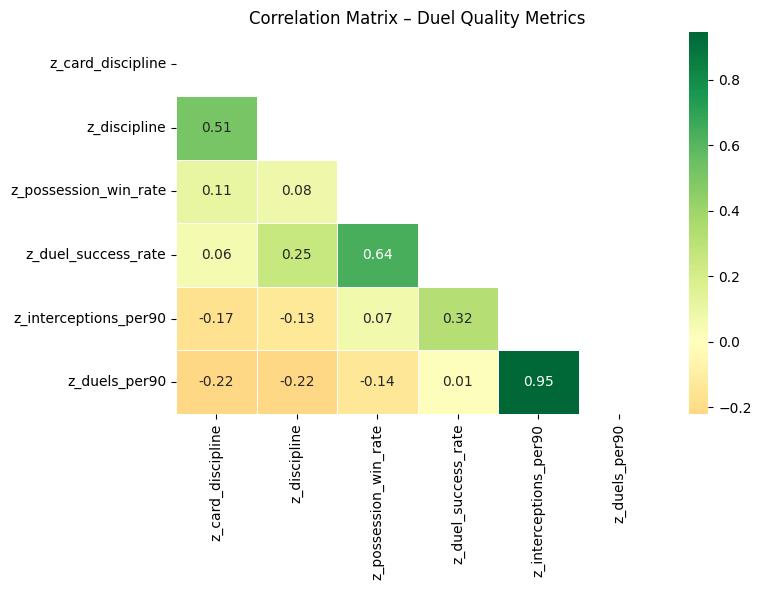

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

corr = z_scores.corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap="RdYlGn",
    center=0,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix – Duel Quality Metrics")
plt.tight_layout()
plt.show()

### Visualising Metric Distributions

Before combining metrics into a single score, it is useful to visualise how each normalised metric is distributed across all qualified players. This helps us spot outliers, check that z-scores look reasonable, and understand how spread out player performance is on each dimension. The custom `DistributionPlot` class overlays a highlighted marker for a specific player of interest.

In [60]:
import sys
sys.path.append(str(pathlib.Path().resolve().parents[0]))
from classes.visual import DistributionPlot

# (Quality) Metrics' Z-Scores Data columns to be used in the Distribution Plot
metrics = [
    "z_card_discipline",
    "z_discipline",
    "z_possession_win_rate",
    "z_duel_success_rate",
    "z_interceptions_per90",
    "z_duels_per90"
]

# Labels for the (Quality) Metrics to be used along the center of the Distribution Plot
Quality_Metric_labels = {
    "z_card_discipline": "Card Discipline",
    "z_discipline": "(Overall) Discipline",
    "z_possession_win_rate": "Possession Win Rate",
    "z_duel_success_rate": "Ground Duel Success Rate",
    "z_interceptions_per90": "Interceptions per-90",
    "z_duels_per90": "Ground Duels per-90",
}

Quality_Metric_label_Value_displayed = {
    "z_card_discipline": "card_discipline",
    "z_discipline": "discipline",
    "z_possession_win_rate": "possession_win_rate",
    "z_duel_success_rate": "duel_success_rate",
    "z_interceptions_per90": "interceptions_per90",
    "z_duels_per90": "duels_per90",
}

# Create distribution plot for z-scores
dist_plot = DistributionPlot(
    columns = metrics,
    labels = ["←  Worse", "Average", "Better  →"],
    quality_metric_labels = Quality_Metric_labels,
    quality_metric_value_columns = Quality_Metric_label_Value_displayed
)

# Add title
dist_plot.add_title(
    title="CB Ground Duel Quality Distribution",
    subtitle=f"Based on {len(duel_summary)} players with ≥30 duels and a playing time ≥350 minutes"
)

# Convert z_scores to dataframe format expected by add_group_data
# and merge the raw metric columns so annotation text can show non-z values.
z_scores_df = z_scores.reset_index()

raw_metric_columns = list(dict.fromkeys(Quality_Metric_label_Value_displayed.values()))
missing_raw_metric_columns = [col for col in raw_metric_columns if col not in duel_summary.columns]
if missing_raw_metric_columns:
    raise KeyError(
        "Missing raw metric column(s) required for annotation values: "
        + ", ".join(missing_raw_metric_columns)
    )

raw_metrics_df = duel_summary[raw_metric_columns].reset_index()

z_scores_df = z_scores_df.merge(
    raw_metrics_df,
    on=["player.id", "player.name"],
    how="left",
    validate="one_to_one",
)

# Add all players as group data (background distribution)
dist_plot.add_group_data(
    df_plot=z_scores_df,
    plots="",  # No suffix needed since columns are already z-scores
    names=z_scores_df["player.name"],
    legend="All players",
    hover="",
    hover_string=""
)

# Highlight specific player (player.id = 370)
selected_player = z_scores_df[z_scores_df["player.id"] == 370]
if not selected_player.empty:
    player_name = selected_player["player.name"].iloc[0]
    dist_plot.add_data_point(
        ser_plot=selected_player.iloc[0],
        plots="",
        name=player_name,
        hover="",
        hover_string=""
    )

# For Jupyter notebooks, use this to display
dist_plot.fig.show()

## Quality Score

With all individual metrics normalised, we now aggregate them into a single composite **Ground Duel Quality Index**. This index captures how well a CB performs across all ground-duel dimensions — volume, success rate, possession recovery, and discipline — relative to all other qualifying CBs in the dataset.

### Building the Composite Ground Duel Quality Index

We combine all six normalised metrics into a single weighted score. The weights reflect the relative importance of each dimension: `possession_win_rate` receives the highest weight (35 %) because directly winning the ball back is the most valuable defensive outcome, while volume and discipline metrics play a supporting role. All weights sum to 1.0.

**This can be adapted based on our needs**

In [61]:
# All weights MUST sum up to = 1.0
weights = {
    "z_duels_per90": 0.1,
    "z_interceptions_per90": 0.15,
    "z_duel_success_rate": 0.2,
    "z_possession_win_rate": 0.35,
    "z_discipline": 0.10,
    "z_card_discipline": 0.10
}

# Verify that weights sum to = 1.0
if not abs(sum(weights.values()) - 1.0) < 1e-10:
    raise ValueError("(Importance) Weights MUST sum to = 1.0 !")

In [62]:
# Creating the Zq_raw metric as a weighted sum of the z-scores:

# Weighted sum: each metric's z-score is multiplied by its importance weight
duel_summary["Zq_raw"] = sum(
    z_scores[m] * w for m, w in weights.items()
)

### Normalising the Composite Score
### ==>  Creating the Global Ground Duel Quality Score/Index: `ground_duel_quality`

The raw weighted sum (`Zq_raw`) already uses z-scored inputs, but its scale varies depending on the weights chosen. We re-standardise it to a final z-score (`ground_duel_quality`) so that the output is always centred at 0 with a standard deviation of 1 — making it easy to compare players across seasons or leagues.

In [63]:
# Creating the Global Ground Duel Quality Score/Index (`ground_duel_quality` == Zq) metric by standardizing `Zq_raw` (with mean = 0 and std = 1):

duel_summary["ground_duel_quality"] = (
    (duel_summary["Zq_raw"] - duel_summary["Zq_raw"].mean())
) / duel_summary["Zq_raw"].std()

### Ranking CBs by Ground Duel Quality

We now sort all qualified CBs by their composite `ground_duel_quality` score in descending order to produce the final ranking. A higher z-score means the player performs better than the average of all CBs on the overall Ground Duel Quality Index.

In [64]:
duel_summary

,,minutes_played,total_duels,won_possession,stopped_progress,foul,lost_duel,yellow_cards,red_cards,duel_success_rate,possession_win_rate,...,interceptions_per90,stops_per90,z_card_discipline,z_discipline,z_possession_win_rate,z_duel_success_rate,z_interceptions_per90,z_duels_per90,Zq_raw,ground_duel_quality
player.id,player.name,,,,,,,,,,,,,,,,,,,,,
479155,N. Collins,3420.0,213,56,89,5,63,2,0,0.680751,0.262911,...,3.815789,2.342105,-0.386663,0.065808,-0.133224,0.172966,0.38172,0.336327,0.04677,0.077142
496001,M. Kilman,3349.0,146,41,58,2,45,2,0,0.678082,0.280822,...,2.660496,1.558674,-0.841082,0.578173,0.13228,0.134523,-0.656938,-0.717745,-0.123404,-0.203541
192792,D. Burn,3330.0,184,48,71,3,62,1,0,0.646739,0.260870,...,3.216216,1.918919,0.030416,0.441599,-0.163482,-0.316928,-0.157322,-0.059985,-0.102999,-0.169887
424241,N. Milenković,3330.0,157,50,62,2,43,0,0,0.713376,0.318471,...,3.027027,1.675676,0.603563,0.628477,0.690371,0.642876,-0.327411,-0.517371,0.392561,0.647487
370,V. van Dijk,3330.0,149,58,53,2,36,0,0,0.744966,0.389262,...,3.000000,1.432432,0.603563,0.592629,1.739724,1.097894,-0.351709,-0.652892,0.830056,1.369088
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
520300,N. Wood,784.0,55,12,23,1,19,1,0,0.636364,0.218182,...,4.017857,2.640306,-1.313876,0.343196,-0.796258,-0.466372,0.563387,0.780414,-0.306483,-0.505511
653730,A. Khusanov,504.0,30,4,16,1,9,1,0,0.666667,0.133333,...,3.571429,2.857143,-2.911742,-0.45094,-2.053999,-0.029901,0.162029,0.180808,-1.018763,-1.680341
327391,J. Bree,490.0,40,5,19,0,16,0,0,0.600000,0.125000,...,4.408163,3.489796,0.603563,1.296158,-2.177527,-0.990138,0.914289,1.427988,-0.490248,-0.808611


In [65]:
# cols = ["ground_duel_quality"]
duel_summary.sort_values("ground_duel_quality", ascending=False).head(15)

,,minutes_played,total_duels,won_possession,stopped_progress,foul,lost_duel,yellow_cards,red_cards,duel_success_rate,possession_win_rate,...,interceptions_per90,stops_per90,z_card_discipline,z_discipline,z_possession_win_rate,z_duel_success_rate,z_interceptions_per90,z_duels_per90,Zq_raw,ground_duel_quality
player.id,player.name,,,,,,,,,,,,,,,,,,,,,
568412,J. Gvardiol,988.0,51,20,23,0,8,0,0,0.843137,0.392157,...,3.917004,2.095142,0.603563,1.296158,1.782639,2.511902,0.472716,-0.265085,1.360675,2.244289
349142,N. Mazraoui,862.0,104,33,39,3,29,0,0,0.692308,0.317308,...,7.517401,4.071926,0.603563,-0.215753,0.673122,0.339421,3.709626,3.628972,1.261599,2.080873
623641,E. Agbadou,1411.0,71,33,21,3,14,0,0,0.760563,0.464789,...,3.444366,1.339476,0.603563,-0.918473,2.859288,1.322545,0.047794,-0.338448,1.207093,1.990972
370,V. van Dijk,3330.0,149,58,53,2,36,0,0,0.744966,0.389262,...,3.000000,1.432432,0.603563,0.592629,1.739724,1.097894,-0.351709,-0.652892,0.830056,1.369088
645877,Y. Mosquera,442.0,34,10,16,1,7,0,0,0.764706,0.294118,...,5.294118,3.257919,0.603563,-0.245399,0.329367,1.382212,1.7108,1.162317,0.800389,1.320156
412968,M. Senesi,1133.0,131,39,50,8,34,2,0,0.679389,0.297710,...,7.069726,3.971756,-1.0065,-1.904632,0.382617,0.15335,3.307147,3.345371,0.704082,1.161308
424806,E. Pinnock,1921.0,109,36,43,0,30,0,0,0.724771,0.330275,...,3.701197,2.014576,0.603563,1.296158,0.865344,0.807003,0.278697,0.023843,0.698432,1.151989
534563,C. Richards,1926.0,160,48,61,3,48,0,0,0.681250,0.300000,...,5.093458,2.850467,0.603563,0.313416,0.416563,0.180151,1.530398,1.50928,0.654013,1.078725
583655,C. Okoli,1145.0,86,26,38,2,20,1,0,0.744186,0.302326,...,5.030568,2.986900,-0.622706,0.077253,0.451036,1.086653,1.473857,1.059992,0.647726,1.068355


In [66]:
# Ranking the Top 15 CBs by Ground Duel Quality Score/Index (`ground_duel_quality` == Zq):

duel_summary["ground_duel_quality"] \
    .sort_values(ascending=False) \
    .head(15)

player.id  player.name  
568412     J. Gvardiol      2.244289
349142     N. Mazraoui      2.080873
623641     E. Agbadou       1.990972
370        V. van Dijk      1.369088
645877     Y. Mosquera      1.320156
412968     M. Senesi        1.161308
424806     E. Pinnock       1.151989
534563     C. Richards      1.078725
583655     C. Okoli         1.068355
283145     T. Adarabioyo    1.023316
590703     I. Zabarnyi      0.988602
400549     Pau Torres       0.975228
447424     C. Bassey        0.950751
346131     T. Chalobah      0.935826
240032     J. Bednarek      0.900543
Name: ground_duel_quality, dtype: object

In [67]:
duel_summary.columns

Index(['minutes_played', 'total_duels', 'won_possession', 'stopped_progress',
       'foul', 'lost_duel', 'yellow_cards', 'red_cards', 'duel_success_rate',
       'possession_win_rate', 'foul_rate', 'discipline', 'card_discipline',
       'duels_per90', 'interceptions_per90', 'stops_per90',
       'z_card_discipline', 'z_discipline', 'z_possession_win_rate',
       'z_duel_success_rate', 'z_interceptions_per90', 'z_duels_per90',
       'Zq_raw', 'ground_duel_quality'],
      dtype='object')

In [68]:
ground_duels_cols = [
    "minutes_played", "total_duels", "yellow_cards", "red_cards",
    "duel_success_rate", "possession_win_rate", "discipline", "card_discipline",
    "duels_per90", "interceptions_per90",
    "z_duel_success_rate", "z_possession_win_rate", "z_discipline",
    "z_card_discipline", "z_duels_per90", "z_interceptions_per90",
    "ground_duel_quality"
]
df_ground_duels = duel_summary[ground_duels_cols].reset_index()

df_ground_duels.sort_values("ground_duel_quality", ascending=False).head(15)

,player.id,player.name,minutes_played,total_duels,yellow_cards,red_cards,duel_success_rate,possession_win_rate,discipline,card_discipline,duels_per90,interceptions_per90,z_duel_success_rate,z_possession_win_rate,z_discipline,z_card_discipline,z_duels_per90,z_interceptions_per90,ground_duel_quality
60,568412,J. Gvardiol,988.0,51,0,0,0.843137,0.392157,1.000000,1.0,4.645749,3.917004,2.511902,1.782639,1.296158,0.603563,-0.265085,0.472716,2.244289
65,349142,N. Mazraoui,862.0,104,0,0,0.692308,0.317308,0.971154,1.0,10.858469,7.517401,0.339421,0.673122,-0.215753,0.603563,3.628972,3.709626,2.080873
46,623641,E. Agbadou,1411.0,71,0,0,0.760563,0.464789,0.957746,1.0,4.528703,3.444366,1.322545,2.859288,-0.918473,0.603563,-0.338448,0.047794,1.990972
4,370,V. van Dijk,3330.0,149,0,0,0.744966,0.389262,0.986577,1.0,4.027027,3.000000,1.097894,1.739724,0.592629,0.603563,-0.652892,-0.351709,1.369088
72,645877,Y. Mosquera,442.0,34,0,0,0.764706,0.294118,0.970588,1.0,6.923077,5.294118,1.382212,0.329367,-0.245399,0.603563,1.162317,1.7108,1.320156
55,412968,M. Senesi,1133.0,131,2,0,0.679389,0.297710,0.938931,0.984733,10.406002,7.069726,0.15335,0.382617,-1.904632,-1.0065,3.345371,3.307147,1.161308
33,424806,E. Pinnock,1921.0,109,0,0,0.724771,0.330275,1.000000,1.0,5.106715,3.701197,0.807003,0.865344,1.296158,0.603563,0.023843,0.278697,1.151989
32,534563,C. Richards,1926.0,160,0,0,0.681250,0.300000,0.981250,1.0,7.476636,5.093458,0.180151,0.416563,0.313416,0.603563,1.50928,1.530398,1.078725
54,583655,C. Okoli,1145.0,86,1,0,0.744186,0.302326,0.976744,0.988372,6.759825,5.030568,1.086653,0.451036,0.077253,-0.622706,1.059992,1.473857,1.068355
44,283145,T. Adarabioyo,1425.0,68,0,0,0.705882,0.352941,1.000000,1.0,4.294737,3.031579,0.534944,1.20133,1.296158,0.603563,-0.485095,-0.323318,1.023316


In [69]:
file_name = "CB_ground_duels.csv"
path = os.path.join(str(pathlib.Path().resolve().parents[0]), "data", "data-CB_pairing_AI_analyst", "Qualities", file_name)

df_ground_duels.to_csv(path, index=True)